In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sunil123kumar/social-media-impact-on-mental-health/Teen_Mental_Health_Dataset.csv


**This dataset is a synthetic dataset made by considering the social media trends and how it affects teenage children mentally.**

## DATA OVERVIEW

In [2]:
df=pd.read_csv('/kaggle/input/datasets/sunil123kumar/social-media-impact-on-mental-health/Teen_Mental_Health_Dataset.csv')
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


**Total 1200 rows and 13 columns**

In [4]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [5]:
df.duplicated().sum()

np.int64(0)

**No duplicate row entries, hence we can go ahead with directly using them for further analysis.**

In [6]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

**No null values either so we can go ahead with using the entries directly for further analysis.**

In [7]:
df['depression_label'].value_counts()

depression_label
0    1169
1      31
Name: count, dtype: int64

**Depression Label is our target variable, it has only two classes 0 and 1, the number of entries lean heavily towards 0, meaning the data is unbalanced.**

In [8]:
df.shape

(1200, 13)

In [9]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

**A simple list of all the columns present in the dataset.**

## DATA CLEANING

In [10]:
for col in df.columns:
    print(col)
    print(df[col].unique())

age
[14 19 17 15 18 16 13]
gender
['male' 'female']
daily_social_media_hours
[7.9 1.9 1.3 7.4 4.7 2.5 4.  3.3 7.2 4.9 6.2 6.8 5.7 3.6 1.5 3.1 6.7 1.2
 3.4 4.1 5.3 2.3 2.4 2.  6.6 1.6 2.7 5.  4.6 4.8 6.3 6.4 7.3 5.2 4.5 3.5
 2.9 5.8 7.1 4.3 3.9 7.5 6.9 1.1 2.6 5.4 5.6 1.8 8.  5.1 3.2 7.7 6.5 7.8
 6.  3.8 2.1 4.4 3.  7.  7.6 6.1 5.9 1.4 4.2 1.7 2.8 2.2 3.7 5.5 1. ]
platform_usage
['Instagram' 'TikTok' 'Both']
sleep_hours
[7.4 8.  7.6 6.9 4.9 4.4 6.4 4.2 5.  5.8 4.7 7.2 5.7 5.9 5.3 6.1 6.8 4.6
 6.7 8.7 7.1 5.6 7.8 7.3 5.5 4.  8.6 7.7 8.8 4.1 4.8 5.1 6.3 8.5 4.5 6.5
 8.2 7.  8.4 4.3 7.5 6.  5.2 9.  5.4 6.6 8.1 7.9 8.9 8.3 6.2]
screen_time_before_sleep
[2.9 0.5 1.6 3.  2.4 2.1 1.5 2.5 2.6 1.1 0.8 0.6 1.4 1.9 1.  1.2 0.9 2.8
 1.3 2.  1.8 2.2 2.3 2.7 0.7 1.7]
academic_performance
[3.01 3.22 3.92 3.48 2.37 2.63 2.4  2.04 3.77 3.16 2.02 3.29 3.5  2.99
 2.59 2.11 3.08 3.85 2.24 2.38 3.69 2.96 2.53 2.15 2.64 3.26 3.83 2.67
 3.05 2.31 3.27 2.01 3.96 2.84 2.43 2.06 3.81 3.42 3.59 3.07 2.22 2.36
 2.

## EDA

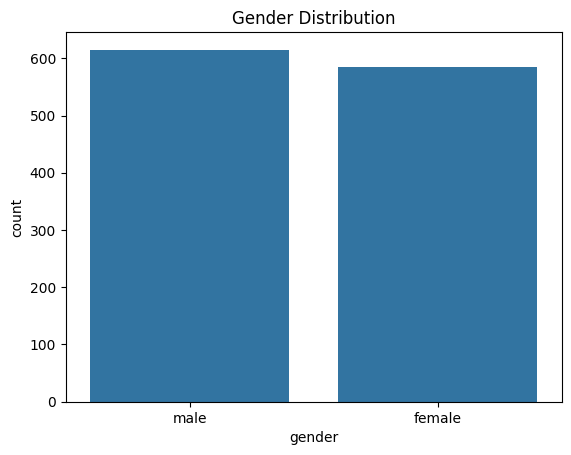

In [11]:
sns.countplot(data=df, x='gender')
plt.title("Gender Distribution")
plt.show()

**More number of male observation entries in the dataset.**

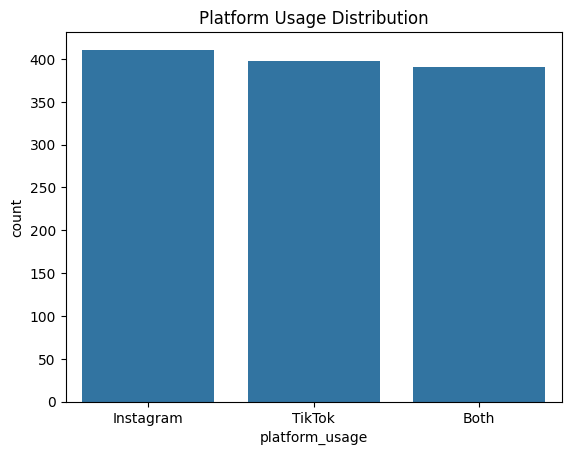

In [12]:
sns.countplot(data=df, x='platform_usage')
plt.title("Platform Usage Distribution")
plt.show()

**The dataset has more entries for Instagram, but Tiktok also comes in a very close second.**

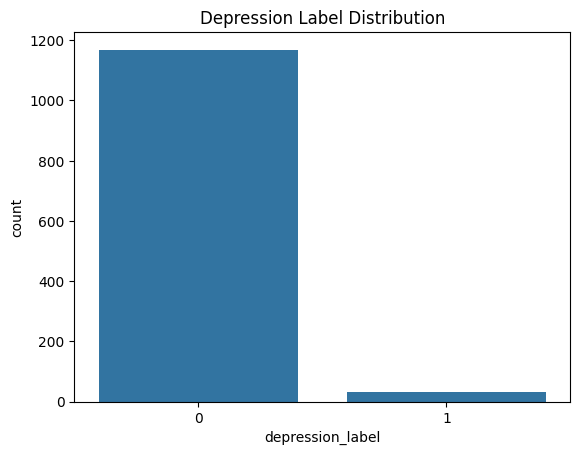

In [13]:
sns.countplot(data=df, x='depression_label')
plt.title("Depression Label Distribution")
plt.show()

**The dataset contains a majority number of people not having depression and a very small minority having depression.**

In [14]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['gender'],
                    df['depression_label'])

chi2,p,dof,expected = chi2_contingency(table)
print(chi2,p)

0.2551540903632945 0.6134690795473368


**The Chi-Square test of independence produced a p-value of 0.613, which is greater than the significance level of 0.05. Therefore, there is insufficient statistical evidence to conclude that gender and depression label are associated in this dataset. This suggests that the distribution of depression labels does not differ significantly between males and females.**

<Axes: xlabel='sleep_hours', ylabel='stress_level'>

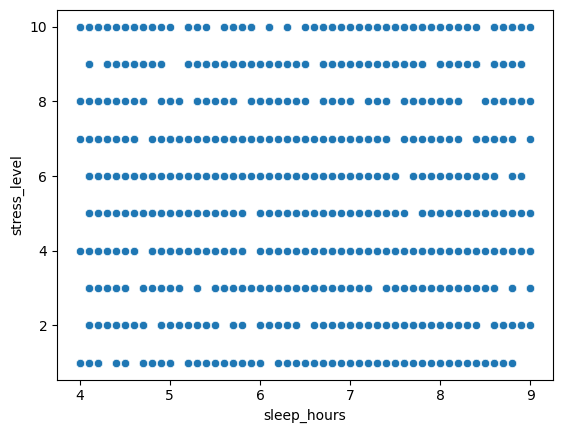

In [15]:
sns.scatterplot(x='sleep_hours',y='stress_level',data=df)

In [16]:
from scipy.stats import pearsonr

r,p = pearsonr(df['sleep_hours'],df['stress_level'])
print(r,p)

-0.010979224324713797 0.7039850772511868


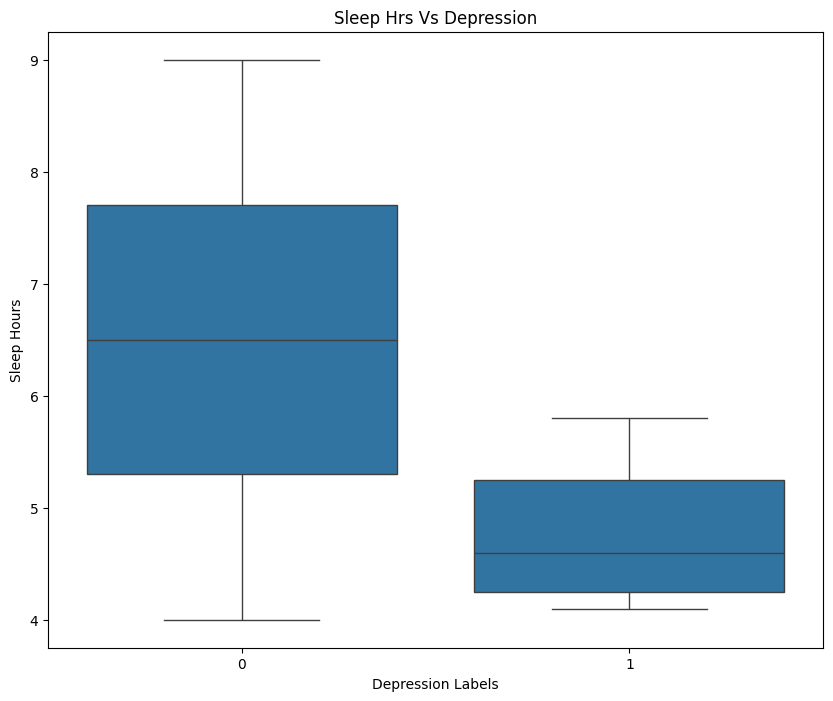

In [17]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df,y='sleep_hours',x='depression_label')
plt.ylabel('Sleep Hours')
plt.xlabel('Depression Labels')
plt.title('Sleep Hrs Vs Depression')
plt.show()

**The boxplots for sleep hours by depression labels do not overlap by a lot, the difference between the median for both the labels is also still big. Hence this can a good measure for our prediction model.**

In [18]:
from scipy.stats import ttest_ind

group0 = df[df['depression_label'] == 0]['sleep_hours']
group1 = df[df['depression_label'] == 1]['sleep_hours']

t_stat, p_value = ttest_ind(group0, group1)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 6.721354868657605
p-value: 2.7783115373186115e-11


**An independent samples t-test was conducted to compare sleep hours between depressed and non-depressed students. The test produced a t-statistic of 6.721 and a p-value of 2.78 × 10⁻¹¹, which is well below the significance level of 0.05. Therefore, we reject the null hypothesis and conclude that there is a statistically significant difference in sleep hours between the two groups.**

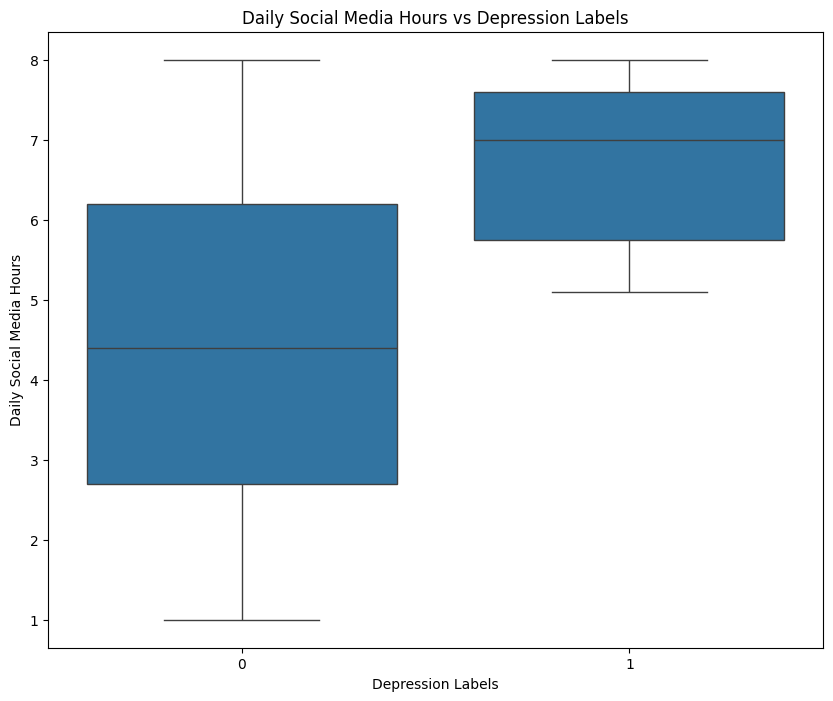

In [19]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df, y='daily_social_media_hours', x='depression_label')
plt.xlabel('Depression Labels')
plt.ylabel('Daily Social Media Hours')
plt.title('Daily Social Media Hours vs Depression Labels')
plt.show()

**Both the labels do not overlap by much in this graph, their medians also stand at a good distance away from each other. Hence Daily Social Media Hours is a good measure to predict depression labels.**

In [20]:
from scipy.stats import ttest_ind

group0 = df[df['depression_label'] == 0]['daily_social_media_hours']
group1 = df[df['depression_label'] == 1]['daily_social_media_hours']

t_stat, p_value = ttest_ind(group0, group1)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -6.159342552049857
p-value: 9.95517965427257e-10


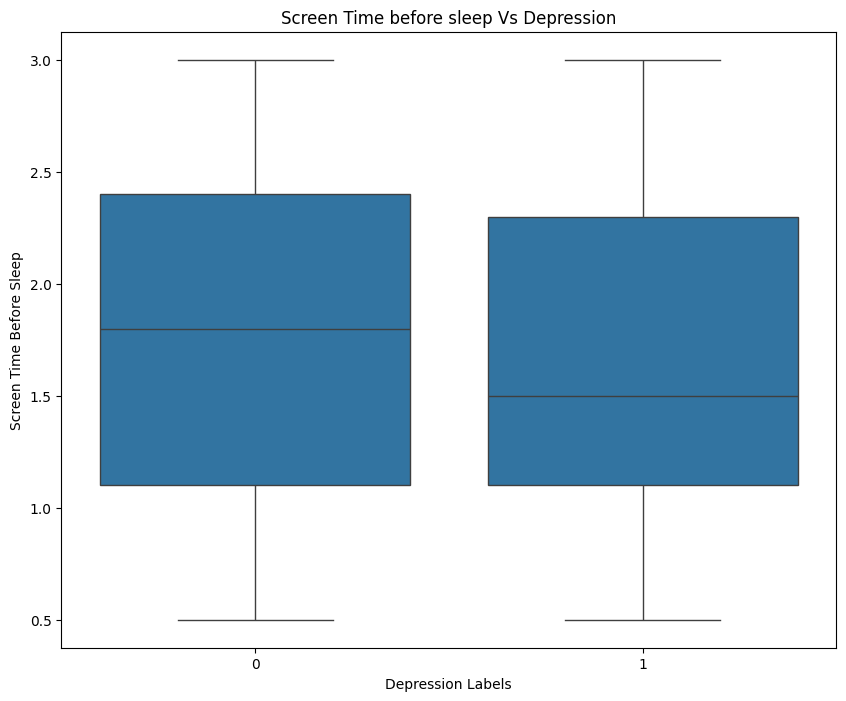

In [21]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df,y='screen_time_before_sleep',x='depression_label')
plt.ylabel('Screen Time Before Sleep')
plt.xlabel('Depression Labels')
plt.title('Screen Time before sleep Vs Depression')
plt.show()

**The boxplots for both the labels overlap by a decent margin, the difference between their medians is also not that high, so this might not be a good measure for our prediction model by itself but it can be used in conjunction with another.**

In [22]:
from scipy.stats import ttest_ind
group0 = df[df['depression_label']==0]['screen_time_before_sleep']
group1 = df[df['depression_label']==1]['screen_time_before_sleep']

t_stat, p_value = ttest_ind(group0, group1)

print(t_stat)
print(p_value)

0.5712343363883565
0.5679479490943541


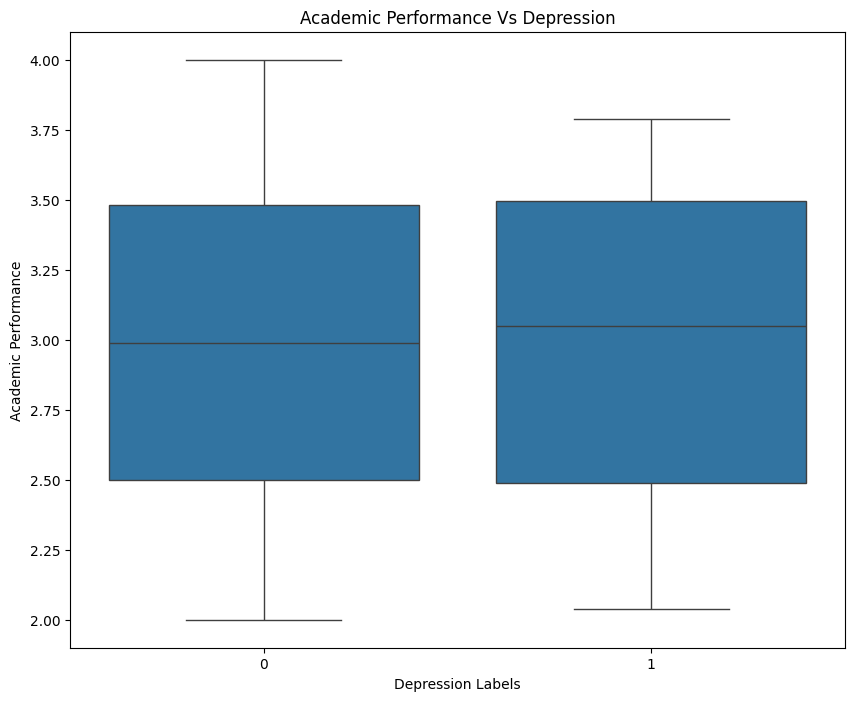

In [23]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df,y='academic_performance',x='depression_label')
plt.ylabel('Academic Performance')
plt.xlabel('Depression Labels')
plt.title('Academic Performance Vs Depression')
plt.show()

**Both the labels here again overlap quite a bit and the difference between their median is pretty low, hence this may not be a good measure by itself for our prediction model but can still be used in conjunction with another.**

In [24]:
from scipy.stats import ttest_ind
group0 = df[df['depression_label']==0]['academic_performance']
group1 = df[df['depression_label']==1]['academic_performance']

t_stat, p_value = ttest_ind(group0, group1)

print(t_stat)
print(p_value)

-0.049866189071991245
0.9602373333064219


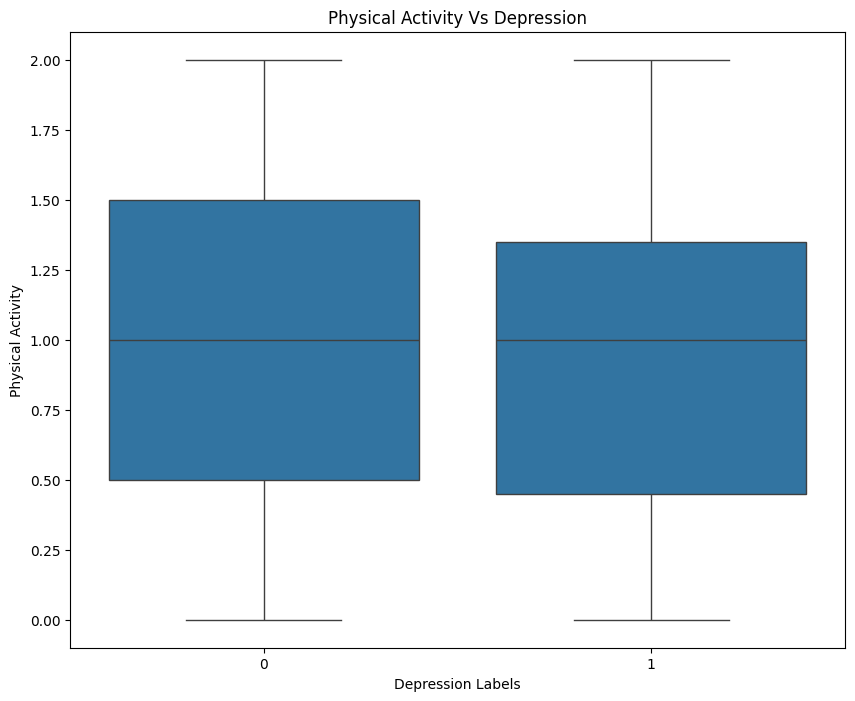

In [25]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df,y='physical_activity',x='depression_label')
plt.ylabel('Physical Activity')
plt.xlabel('Depression Labels')
plt.title('Physical Activity Vs Depression')
plt.show()

**Once again, labels overlap quite a bit, and so does their median, hence not a good measure by itself for our prediction model.**

In [26]:
from scipy.stats import ttest_ind

group0 = df[df['depression_label']==0]['physical_activity']
group1 = df[df['depression_label']==1]['physical_activity']

t_stat, p_value = ttest_ind(group0, group1)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 0.6091877307246268
p-value: 0.542515516292257


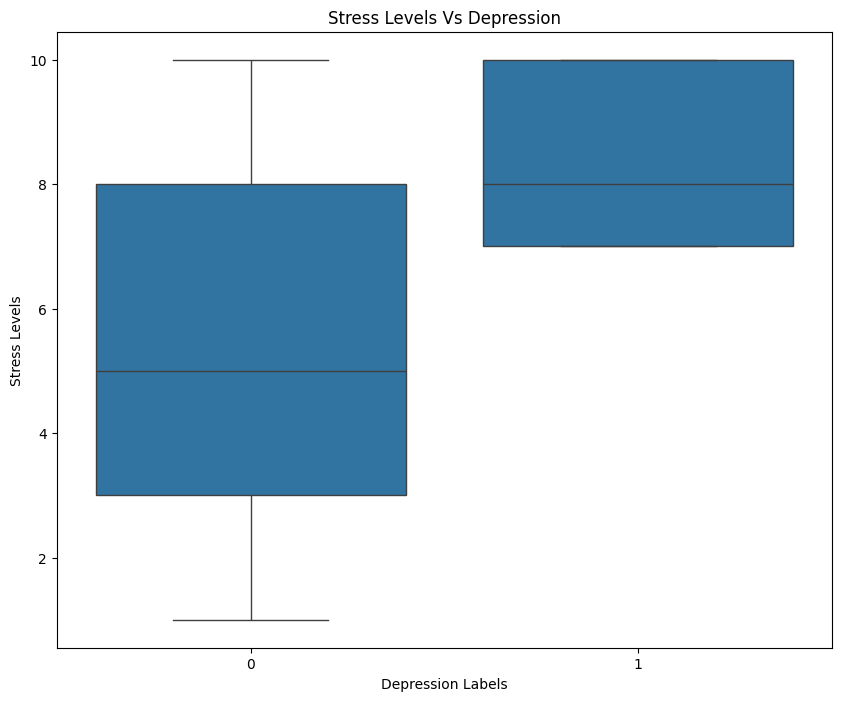

In [27]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df,y='stress_level',x='depression_label')
plt.ylabel('Stress Levels')
plt.xlabel('Depression Labels')
plt.title('Stress Levels Vs Depression')
plt.show()

**The labels in this case do not overlap by that much hence this can be a good measure for our prediction model.**

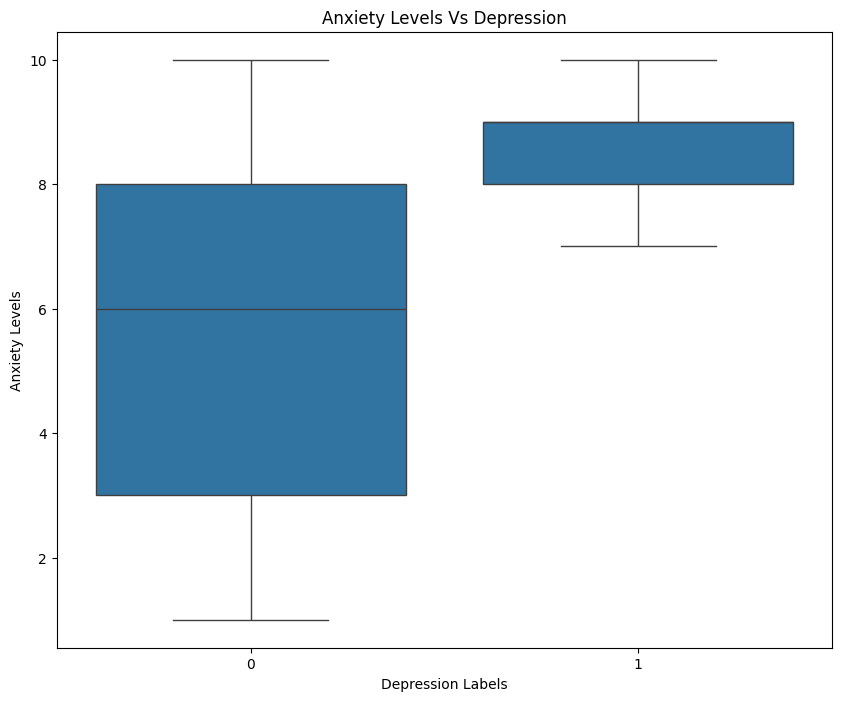

In [28]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df,y='anxiety_level',x='depression_label')
plt.ylabel('Anxiety Levels')
plt.xlabel('Depression Labels')
plt.title('Anxiety Levels Vs Depression')
plt.show()

**The labels do not overlap by much making it a good measure for our prediction model.**

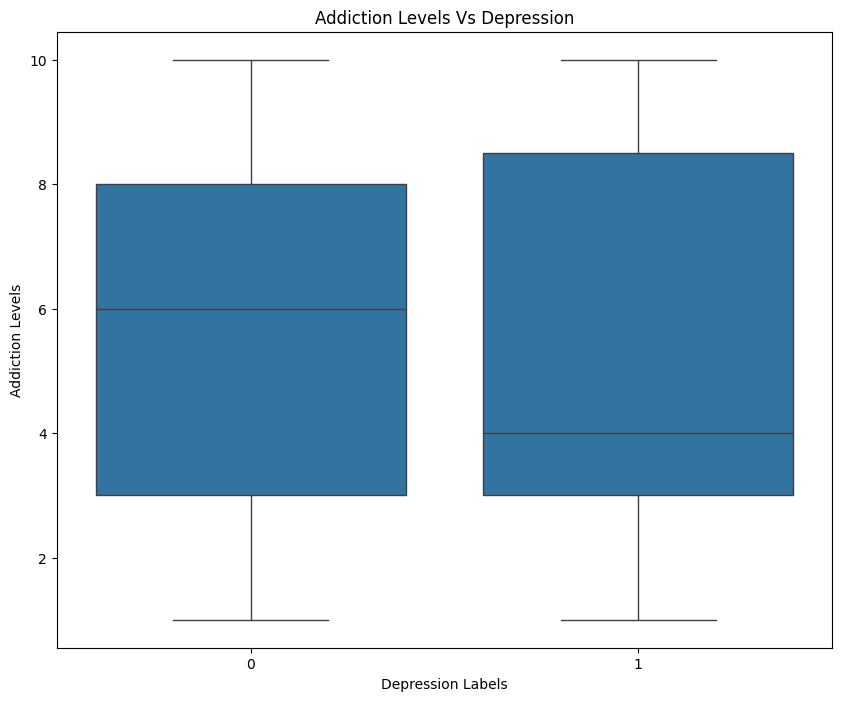

In [29]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df,y='addiction_level',x='depression_label')
plt.ylabel('Addiction Levels')
plt.xlabel('Depression Labels')
plt.title('Addiction Levels Vs Depression')
plt.show()

**The labels overlap by quite a lot, hence not a good measure by itself for our prediction model, can still be used in conjunction with another.**

In [30]:
from scipy.stats import ttest_ind

features = ['sleep_hours','daily_social_media_hours','screen_time_before_sleep','academic_performance','physical_activity',
            'stress_level','anxiety_level','addiction_level']

for feature in features:
    group0 = df[df['depression_label'] == 0][feature]
    group1 = df[df['depression_label'] == 1][feature]

    t_stat, p_value = ttest_ind(group0, group1)

    print(f"\n{feature}")
    print(f"t-statistic: {t_stat}")
    print(f"p-value: {p_value}")


sleep_hours
t-statistic: 6.721354868657605
p-value: 2.7783115373186115e-11

daily_social_media_hours
t-statistic: -6.159342552049857
p-value: 9.95517965427257e-10

screen_time_before_sleep
t-statistic: 0.5712343363883565
p-value: 0.5679479490943541

academic_performance
t-statistic: -0.049866189071991245
p-value: 0.9602373333064219

physical_activity
t-statistic: 0.6091877307246268
p-value: 0.542515516292257

stress_level
t-statistic: -5.9881120950558655
p-value: 2.802296558200422e-09

anxiety_level
t-statistic: -5.955286471857322
p-value: 3.407107442153346e-09

addiction_level
t-statistic: 0.4829585684019488
p-value: 0.6292133973463196


Sleep hours differ significantly between depressed and non-depressed students. This confirms the visual separation observed in the boxplot, suggesting that sleep hours are an important feature for distinguishing between the two groups.
Daily social media usage differs significantly between depressed and non-depressed students. This indicates that social media usage is likely an informative predictor of depression status.
There is no statistically significant difference in screen time before sleep between depressed and non-depressed students. Although the boxplot may have shown some variation, the observed difference is not statistically significant in this dataset.
Academic performance does not differ significantly between the two depression groups. Based on this dataset, academic performance alone is unlikely to be a strong indicator of depression status.
Physical activity does not show a statistically significant difference between depressed and non-depressed students. Therefore, there is insufficient evidence to conclude that physical activity alone distinguishes the two groups.
Stress levels differ significantly between depressed and non-depressed students. This supports the observation from the boxplot and indicates that stress level is an important feature for predicting depression.
Anxiety levels differ significantly between the two depression groups. This suggests that anxiety level is a valuable predictor of depression status.
Addiction level does not differ significantly between depressed and non-depressed students in this dataset. Therefore, there is insufficient statistical evidence to consider it an important standalone predictor.

In [31]:
from statsmodels.multivariate.manova import MANOVA

manova = MANOVA.from_formula(
    'sleep_hours + daily_social_media_hours + screen_time_before_sleep + '
    'academic_performance + physical_activity + stress_level + '
    'anxiety_level + addiction_level ~ depression_label',
    data=df
)

result = manova.mv_test()

wilks = result.results['depression_label']['stat'].loc["Wilks' lambda"]

print(wilks)

Value       0.879896
Num DF             8
Den DF        1191.0
F Value    20.321198
Pr > F           0.0
Name: Wilks' lambda, dtype: object


<Axes: >

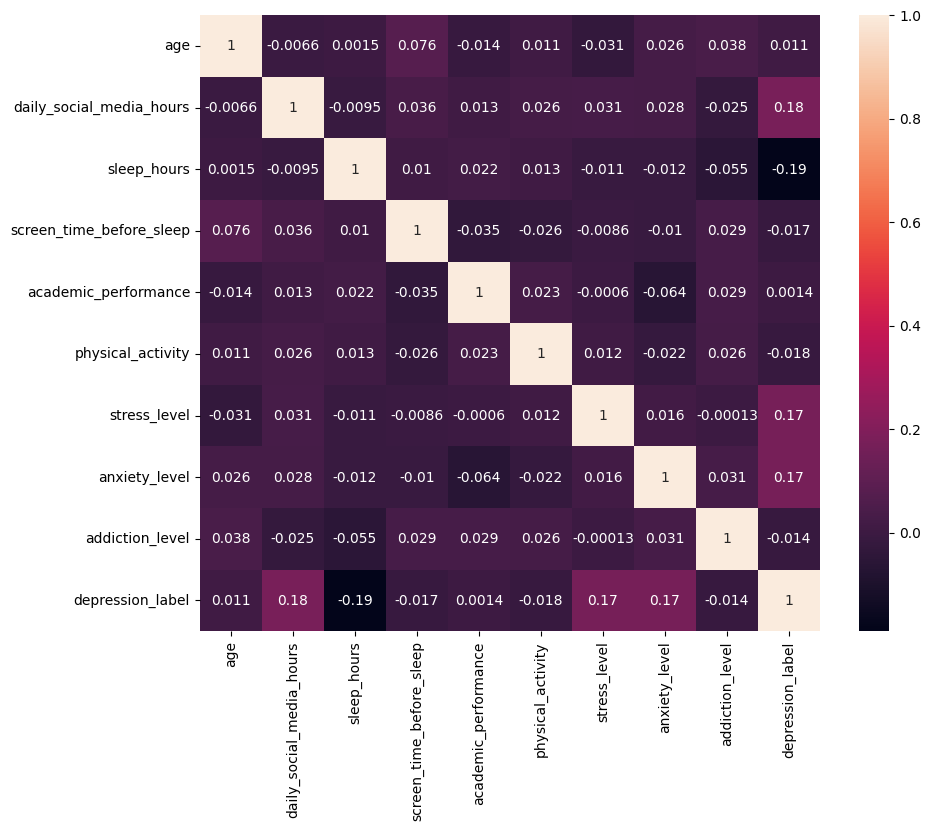

In [32]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)

**The correlation heatmap shows that none of the independent variables are highly correlated with one another, indicating the absence of significant multicollinearity. While a few variables exhibit weak correlations with the target variable (depression_label), none individually demonstrate a strong linear relationship. Therefore, all predictor variables were retained for model development, allowing the model to learn from the combined information provided by all features.**

## MODEL

In [33]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['gender'] = label_encoder.fit_transform(df['gender'])
df['social_interaction_level'] = label_encoder.fit_transform(df['social_interaction_level'])

In [34]:
df=pd.get_dummies(df,columns=['platform_usage'], dtype=int)

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

X = df.drop(columns='depression_label')

y = df['depression_label']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print()

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()

print("Classification Report:")
print(classification_report(y_test, y_pred))

Training Accuracy: 0.9854
Testing Accuracy: 0.9792

Confusion Matrix:
[[234   0]
 [  5   1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       234
           1       1.00      0.17      0.29         6

    accuracy                           0.98       240
   macro avg       0.99      0.58      0.64       240
weighted avg       0.98      0.98      0.97       240



**Our first model gives us a very high accuracy, but our recall is very low, meaning that out of all the people which are truly depressed, we are correctly finding a very small amount of them, while precision being high tells us that out of all the predicted values all of them were correct to a very great degree but it guesses the 'not depressed', i.e. the 1 category less all in all. This happens due to an overwhelming majority of the entries in the dataset not being depressed and a very small minority being depressed, hence it leads to data imbalance.**

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

X = df.drop(columns='depression_label')

y = df['depression_label']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(class_weight='balanced',max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print()

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()

print("Classification Report:")
print(classification_report(y_test, y_pred))

print(df.shape)
print(X.shape)
print(y_train.describe())
print(y_test.describe())

Training Accuracy: 0.9458
Testing Accuracy: 0.9458

Confusion Matrix:
[[222  12]
 [  1   5]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       234
           1       0.29      0.83      0.43         6

    accuracy                           0.95       240
   macro avg       0.64      0.89      0.70       240
weighted avg       0.98      0.95      0.96       240

(1200, 15)
(1200, 14)
count    960.000000
mean       0.026042
std        0.159342
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: depression_label, dtype: float64
count    240.000000
mean       0.025000
std        0.156451
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: depression_label, dtype: float64


**In this model we just add a weight balance, to cover up for the imbalance between the number of depressed and not depressed entries.**